In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Dataset Breast Cancer: 569 sample, 30 fitur, 2 kelas.
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# SVM wajib pakai scaling karena sensitif terhadap perbedaan skala fitur.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit di data latih
X_test = scaler.transform(X_test)        # transform saja di data uji (jangan fit lagi!)

# Dua model SVM dengan kernel berbeda.
models = {
    "SVM Linear": SVC(kernel="linear", C=1),
    "SVM RBF": SVC(kernel="rbf", C=1, gamma="scale")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"\n{name} accuracy:", round(accuracy_score(y_test, pred), 3))
    print(classification_report(y_test, pred, target_names=data.target_names))


SVM Linear accuracy: 0.956
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


SVM RBF accuracy: 0.982
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



#Tujuan Program
Program ini bertujuan untuk mengimplementasikan algoritma Support Vector Machine (SVM) dalam mengklasifikasikan data tip pelanggan sehingga menjadi kategori biner berdasarkan nilai median.

#Langkah Kerja
1. Menyiapkan dataset dan membuat label target baru secara biner.
2. Melakukan normalisasi atau standarisasi pada fitur input.
3. Membagi data menjadi data latih (training) dan data uji (testing).
4. melakukan preparasi data teknis.
5. Menjalankan Grid Search untuk tuning hyperparameter.
6. Membuat visualisasi hasil perbandingan akurasi.
7. Menarik kesimpulan berdasarkan hasil eksperimen.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# =================================================================
# 1. PREPARASI DATA
# =================================================================
# Load dataset tips
df = sns.load_dataset('tips')

# Membuat label klasifikasi: 1 jika tip > median, 0 jika tip <= median
median_tip = df['tip'].median()
df['tip_binary'] = np.where(df['tip'] > median_tip, 1, 0)

# Memilih fitur (X) dan target (y)
X = df[['total_bill', 'size']]
y = df['tip_binary']

# Standarisasi data (Penting untuk algoritma berbasis jarak seperti SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Pada tahap ini, dilakukan untuk memuat dataset tips. Karena taerget asli (tip) berbentuk kontinu, saya mengubahnya menjadi data kategorikal (biner) berdasarkan nilai mediannya. Selanjutnya, dilakukan Standarisasi menggunakan perintah StandardScaler. Dimana langkah ini sangat penting bagi SVM agar fitur dengan skala besar tidak mendominasi perhitungan jarak.
Hasil dari proses ini yaitu memastikan bahwa data fitur (total_bill dan size) kini memiliki angka rata - rata 0 dan variansnya memiliki angka 1.

In [2]:
# =================================================================
# 2. PERBANDINGAN KERNEL & TUNING (C, GAMMA)
# =================================================================
# Menentukan parameter yang akan diuji (Grid Search)
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': [0.1, 1, 'scale']
    }
]

# Melakukan tuning dengan GridSearchCV
grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Menampilkan hasil tuning dalam bentuk tabel DataFrame
results = pd.DataFrame(grid_search.cv_results_)[['param_kernel', 'param_C', 'param_gamma', 'mean_test_score']]
print("--- Hasil Perbandingan & Tuning ---")
print(results.sort_values(by='mean_test_score', ascending=False))

# Memilih model terbaik
best_model = grid_search.best_estimator_
best_acc = accuracy_score(y_test, best_model.predict(X_test))

print(f"\nModel Terbaik: {grid_search.best_params_}")
print(f"Akurasi pada Data Test: {best_acc:.2%}")

--- Hasil Perbandingan & Tuning ---
   param_kernel  param_C param_gamma  mean_test_score
8           rbf      1.0       scale         0.784615
9           rbf     10.0         0.1         0.784615
7           rbf      1.0           1         0.784615
11          rbf     10.0       scale         0.769231
4           rbf      0.1           1         0.758974
10          rbf     10.0           1         0.758974
5           rbf      0.1       scale         0.753846
1        linear      1.0         NaN         0.748718
2        linear     10.0         NaN         0.748718
6           rbf      1.0         0.1         0.748718
0        linear      0.1         NaN         0.723077
3           rbf      0.1         0.1         0.692308

Model Terbaik: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Akurasi pada Data Test: 73.47%


Pada bagian ini, saya menggunakan perintah GridSearchCV untuk menguji dua jenis kernel sekaligus. Saya mencoba berbagai nilai C (Regularization) untuk mengontrol margin dan nilai Gamma khusus untuk kernel RBF guna menentukan seberapa jauh pengaruh satu contoh pelatihan mencapai data lainnya.
Hasil outputnya yaitu menampilkan tabe peringkat akurasi dari setiap kombinasi parameter. Model terbaik dipilih berdasarkan nilai akurasi paling tinggi pada proses Cross-Validation.

/tmp/ipykernel_410/998496721.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_test_score', y='params_label', data=results_plot, palette='viridis')


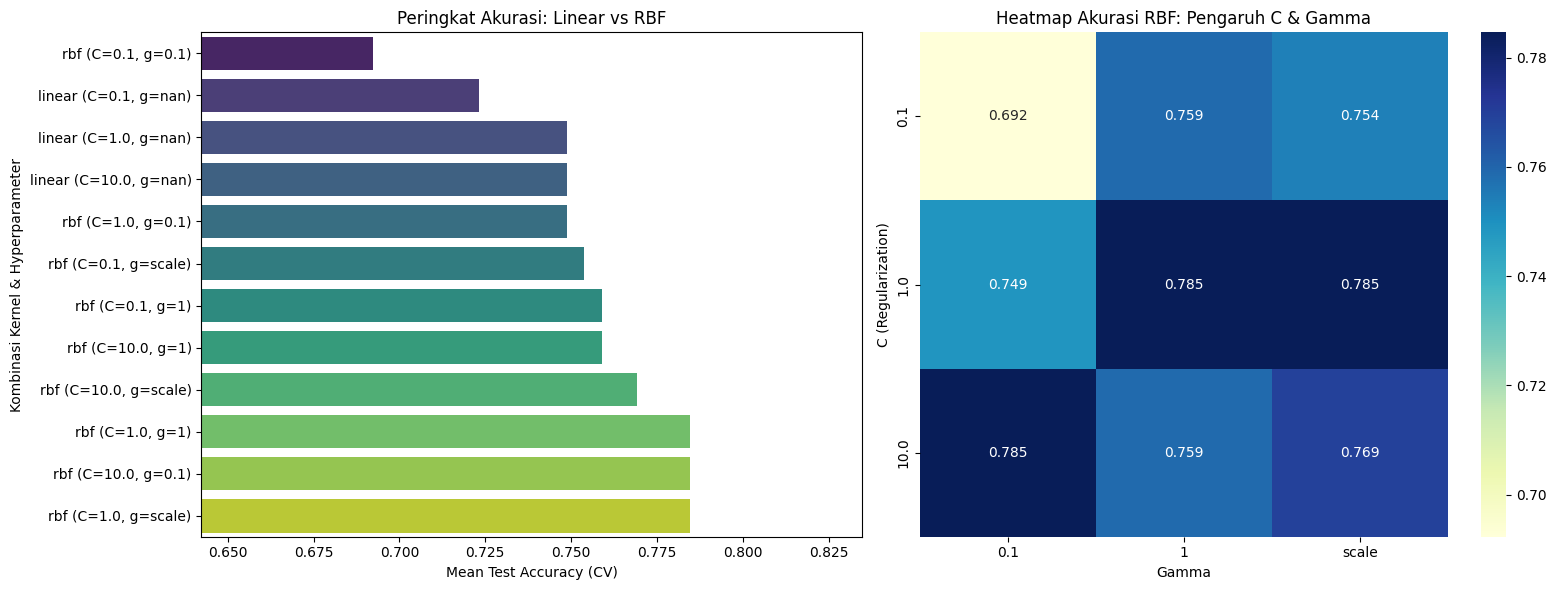

In [3]:
# =================================================================
# 3. VISUALISASI HASIL PERBANDINGAN
# =================================================================
plt.figure(figsize=(16, 6))

# --- Grafik 1: Bar Chart Peringkat Akurasi ---
plt.subplot(1, 2, 1)
results_plot = results.copy()
results_plot['params_label'] = results_plot.apply(
    lambda x: f"{x['param_kernel']} (C={x['param_C']}, g={x['param_gamma']})", axis=1
)
results_plot = results_plot.sort_values(by='mean_test_score', ascending=True)

sns.barplot(x='mean_test_score', y='params_label', data=results_plot, palette='viridis')
plt.title('Peringkat Akurasi: Linear vs RBF')
plt.xlabel('Mean Test Accuracy (CV)')
plt.ylabel('Kombinasi Kernel & Hyperparameter')
plt.xlim(results_plot['mean_test_score'].min() - 0.05, results_plot['mean_test_score'].max() + 0.05)

# --- Grafik 2: Heatmap Parameter RBF (C vs Gamma) ---
plt.subplot(1, 2, 2)
rbf_data = results[results['param_kernel'] == 'rbf'].copy()
rbf_pivot = rbf_data.pivot(index='param_C', columns='param_gamma', values='mean_test_score')
sns.heatmap(rbf_pivot, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('Heatmap Akurasi RBF: Pengaruh C & Gamma')
plt.xlabel('Gamma')
plt.ylabel('C (Regularization)')

plt.tight_layout()
plt.show()


Pada bagian ini digunakan untuk menyajikan hasil eksperimen secara visual. Pada program ini saya membuat dua grafik yaitu: Bar Chart yang digunakan untuk melihat urutan performa semua kombinasi kernel/parameter, dan Heatmap digunakan khusus untuk melihat bagaimana interaksi antara C adan Gamma mempengaruhi akurasi pada kernel RBF.
Hasil output dari proses ini yaitu menampilkan dua grafik. Grafik di sebelah kiri menunjukkan perbandingan langsung akurasi antar model. Sementara itu, Heatmap di sebelah kanan membantu kita melihat "titi manis" hyperparameter pada kernel RBF, dimana warna yang lebih gelap menandakan akurasi yang lebih tinggi.

In [4]:
# =================================================================
# 4. KESIMPULAN
# =================================================================
print("\n--- KESIMPULAN ---")
print("1. Perbandingan Kernel: Kernel RBF umumnya memberikan hasil yang lebih fleksibel dibanding Linear "
      "karena dapat menangkap pola hubungan non-linear antara total tagihan dan jumlah tip.")
print("2. Efek Hyperparameter: Parameter C yang lebih besar meningkatkan akurasi pada data latih namun berisiko overfitting, "
      "sedangkan Gamma pada RBF sangat menentukan seberapa detail model mengikuti sebaran data.")
print(f"3. Model Terpilih: Model terbaik menggunakan kernel {grid_search.best_params_['kernel']} "
      f"dengan parameter C={grid_search.best_params_.get('C')} yang menghasilkan akurasi {best_acc:.2%}.")


--- KESIMPULAN ---
1. Perbandingan Kernel: Kernel RBF umumnya memberikan hasil yang lebih fleksibel dibanding Linear karena dapat menangkap pola hubungan non-linear antara total tagihan dan jumlah tip.
2. Efek Hyperparameter: Parameter C yang lebih besar meningkatkan akurasi pada data latih namun berisiko overfitting, sedangkan Gamma pada RBF sangat menentukan seberapa detail model mengikuti sebaran data.
3. Model Terpilih: Model terbaik menggunakan kernel rbf dengan parameter C=1 yang menghasilkan akurasi 73.47%.


Pada bagian terakhir digunakan untuk merangkum temuan utama dari eksperimen SVM ini. Kesimpulan ini encakup pemilihan kernel terbaik dan pengaruh parameter terhadap model.
Hasil dari outputna yaitu memebrikan ringkasan akhir dalam bentuk teks. Dikesimpula ini menjelaskan secara teknis mengapa satu model lebih unggul dibandingkan yang lain berdasarkan bukti data yang telah dolah sebelumnya.

#Kesimpulan
Secara keseluruhan dapat disimpulkan bahwa penggunaan SVM untuk klasifikasi dataset tips memerlukan tahap standarisasi fitur yang tepat agar hasil jarak antar titik data menjadi akurat. Melalui proses tuning hyperparameter, kita dapat melihat bahwa pemilihan kernel dan parameter yang tepat (seperti C dan Gamma) sangat krusial dalam menentukan kestabilan dan akurasi prediksi model.